In [1]:
!pip install yfinance praw pandas

In [2]:
import yfinance as yf
import pandas as pd
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
#GameStop stock data
stock = yf.download("GME", start="2021-01-01", end="2021-03-01")
print(stock.head())

[*********************100%***********************]  1 of 1 completed

Price        Close    High     Low    Open    Volume
Ticker         GME     GME     GME     GME       GME
Date                                                
2021-01-04  4.3125  4.7750  4.2875  4.7500  40090000
2021-01-05  4.3425  4.5200  4.3075  4.3375  19846000
2021-01-06  4.5900  4.7450  4.3325  4.3350  24224800
2021-01-07  4.5200  4.8625  4.5050  4.6175  24517200
2021-01-08  4.4225  4.5750  4.2700  4.5450  25928000


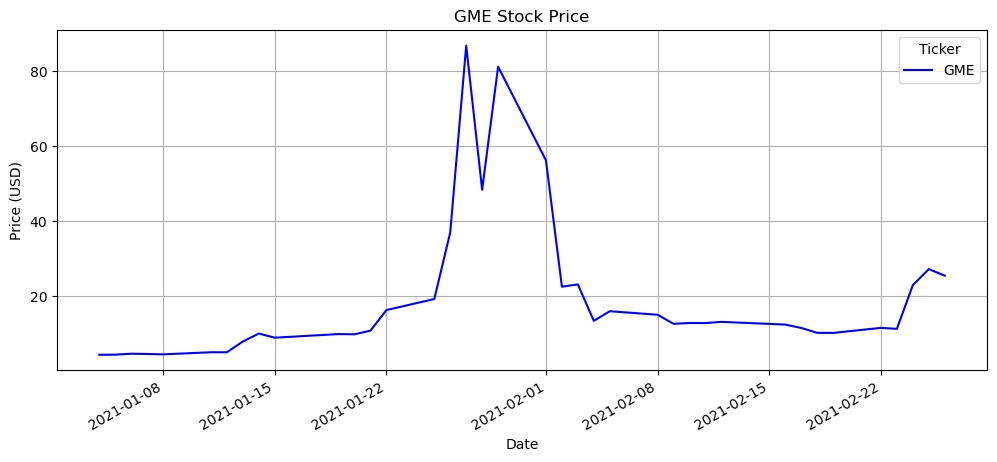

In [4]:
#visualizing
import matplotlib.pyplot as plt
stock["Close"].plot(title="GME Stock Price", figsize=(12,5), color="blue")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

In [5]:
import os
os.makedirs("../data", exist_ok=True)

stock.to_csv("../data/gme_stock.csv")
print("Stock data saved successfully!")

Stock data saved successfully!


In [8]:
stock.to_csv("../data/gme_stock.csv")
print("Stock data saved successfully!")

Stock data saved successfully!


In [9]:
import os
print(os.listdir(r"C:\Users\praful\Desktop\sentiment-stock-analysis\data"))

['desktop.ini', 'gme_reddit.csv', 'gme_stock.csv', 'r_wallstreetbets_posts.csv']


In [10]:
import pandas as pd

reddit = pd.read_csv(
    r"C:\Users\praful\Desktop\sentiment-stock-analysis\data\r_wallstreetbets_posts.csv",
    nrows=1000
)
print(reddit.shape)
print(reddit.head())

(1000, 12)
       id                                              title  score  \
0  ll0n5k                          Whats going on with PLTR?      1   
1  ll0n4p  Need explanations on Level 2 data for GME, why...      1   
2  ll0my2       XRT is being used as a laundry short machine      1   
3  ll0mxr                                          Airlines?      1   
4  ll0mx4                                         Buy TRXC 🚀      1   

           author author_flair_text removed_by  total_awards_received  \
0        Zaccko98               NaN  moderator                    0.0   
1       toutoucnc       210115:1:1  moderator                    0.0   
2          thabat               NaN  moderator                    0.0   
3     AsianTwink_               NaN  moderator                    0.0   
4  Oneverystreet8               NaN  moderator                    0.0   

  awarders  created_utc                                          full_link  \
0       []   1613469192  https://www.reddit.c

In [11]:
print(reddit.columns.tolist())
print(f"\nTotal rows in full dataset: checking...")

import pandas as pd
reddit['created_utc'] = pd.to_datetime(reddit['created_utc'], unit='s')
print(reddit['created_utc'].min())
print(reddit['created_utc'].max())

['id', 'title', 'score', 'author', 'author_flair_text', 'removed_by', 'total_awards_received', 'awarders', 'created_utc', 'full_link', 'num_comments', 'over_18']

Total rows in full dataset: checking...
2021-02-16 01:38:04
2021-02-16 09:53:12


In [12]:
# Filtering GME posts from 1000 rows
gme_posts = reddit[reddit['title'].str.contains('GME|GameStop|gamestop', case=False, na=False)]
print(f"GME related posts: {len(gme_posts)}")

gme_posts.to_csv(
    r"C:\Users\praful\Desktop\sentiment-stock-analysis\data\gme_reddit.csv",
    index=False
)
print("Reddit data saved!")

GME related posts: 82
Reddit data saved!


In [1]:
import pandas as pd
reddit = pd.read_csv(
    r"C:\Users\praful\Desktop\sentiment-stock-analysis\data\r_wallstreetbets_posts.csv",
    nrows=1000
)

gme_posts = reddit[
    reddit['title'].str.contains('GME|GameStop|gamestop', case=False, na=False)
]

gme_posts.to_csv(
    r"C:\Users\praful\Desktop\sentiment-stock-analysis\data\gme_reddit.csv",
    index=False
)
print(f"Saved {len(gme_posts)} GME posts!")

Saved 82 GME posts!


In [2]:
import pandas as pd

reddit = pd.read_csv(
    r"C:\Users\praful\Desktop\madhulika\sentiment stock analysis\data\r_wallstreetbets_posts.csv",
    nrows=1000
)

gme_posts = reddit[
    reddit['title'].str.contains('GME|GameStop|gamestop', case=False, na=False)
]

gme_posts.to_csv(
    r"C:\Users\praful\Desktop\madhulika\sentiment stock analysis\data\gme_reddit.csv",
    index=False
)
print(f"Saved {len(gme_posts)} GME posts!")

Saved 82 GME posts!


In [1]:
import pandas as pd
reddit = pd.read_csv(
    r"C:\Users\praful\Desktop\madhulika\sentiment stock analysis\data\r_wallstreetbets_posts.csv",
    nrows=50000
)

gme_posts = reddit[
    reddit['title'].str.contains('GME|GameStop|gamestop', case=False, na=False)
]

print(f"GME posts found: {len(gme_posts)}")
print(gme_posts['created_utc'].min(), "to", gme_posts['created_utc'].max())

GME posts found: 3889
1612808162 to 1613469189


In [4]:
reddit = pd.read_csv(
    r"C:\Users\praful\Desktop\madhulika\sentiment stock analysis\data\r_wallstreetbets_posts.csv"
)

print(f"Total rows: {len(reddit)}")
print(pd.to_datetime(reddit['created_utc'], unit='s').min(), "to", pd.to_datetime(reddit['created_utc'], unit='s').max())

C:\Users\praful\AppData\Local\Temp\ipykernel_37576\2776183623.py:1: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  reddit = pd.read_csv(


Total rows: 1118863
2012-04-11 16:40:40 to 2021-02-16 09:53:12


In [5]:
gme_posts = reddit[
    reddit['title'].str.contains('GME|GameStop|gamestop', case=False, na=False)
]
gme_posts = gme_posts[['id', 'title', 'score', 'created_utc', 'num_comments']]
gme_posts['created_utc'] = pd.to_datetime(gme_posts['created_utc'], unit='s')
gme_posts = gme_posts.rename(columns={'created_utc': 'date'})
gme_posts['date'] = gme_posts['date'].dt.date
gme_posts = gme_posts.reset_index(drop=True)

print(f"Total GME posts: {len(gme_posts)}")
print(f"Date range: {gme_posts['date'].min()} to {gme_posts['date'].max()}")

gme_posts.to_csv(
    r"C:\Users\praful\Desktop\madhulika\sentiment stock analysis\data\gme_reddit_clean.csv",
    index=False
)
print("Saved!")

Total GME posts: 106930
Date range: 2012-06-01 to 2021-02-16
Saved!
